# Watts-Strogatz Model

This notebook builds upon `synthetic-data.ipynb` to also compare against the Watts-Strogatz model.

In [1]:
SEED = 0
# Standard library dependencies
import sys
import random
import time
import warnings
from typing import Optional


# External dependencies
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe
import scipy # for version name
from scipy import stats
from scipy.special import comb

# My code 
import GmGM

# Wrappers for prior work
import BiGLasso_Methods as bg

In [2]:
print(f"Python version:\n\t{sys.version}\n--\n")
print(f"Numpy version: {np.__version__}")
print(f"igraph version: {ig.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"GmGM version: {GmGM.__version__}")
print(f"BiGLasso_Methods version: {bg.__version__}")

Python version:
	3.9.19 | packaged by conda-forge | (main, Mar 20 2024, 12:55:20) 
[Clang 16.0.6 ]
--

Numpy version: 1.25.2
igraph version: 0.11.5
Matplotlib version: 3.9.4
Scipy version: 1.12.0
GmGM version: 0.5.6
BiGLasso_Methods version: 1.0.0


In [3]:
# Make palette colorblind friendly
plt.style.use('tableau-colorblind10')
hatches = ['|', '//', 'oo', 'x', '+', '-', 'OO', '.', '*', '\\']
lines = ['-', '--', '-.', ':', (0, (3, 5, 1, 5, 1, 5))]

# Building blocks

Skip down to the "Experiments" section to see the actual experiments, this is just setup code.

In [4]:
# Helper functions to compute fast Kronecker sum
def kron_sum_diag_fast(
    *lams: list[np.ndarray]
) -> np.ndarray:
    # Setup
    ds = [len(lam) for lam in lams]
    d_lefts = np.cumprod([1] + ds[:-1]).astype(int)
    d_rights = np.cumprod([1] + ds[::-1])[-2::-1].astype(int)
    total = d_rights[0] * ds[0]
    out = np.zeros(total)
    
    
    for ell, lam in enumerate(lams):
        add_like_kron_sum(
            out,
            lam,
            ds[ell],
            d_lefts[ell],
            d_rights[ell]
        )
        
    return out

def add_like_kron_sum(
    cur_kron_sum: np.ndarray,
    to_add: np.ndarray,
    d: int,
    d_left: int,
    d_right: int
) -> None:
    """
    !!!!Modifies cur_kron_sum in place!!!!
    
    Let X[+]Y be the Kronecker sum
    of diagonal matrices.
    Sometimes we want to find X[+](Y+Z)
    for diagonal Z
    
    This is a way to update our pre-computed
    X[+]Y to incorporate the additive Z.

    Old typing hint:
        cur_kron_sum: "Kronsummed matrix",
        to_add: "What to add to matrix",
        ell: "Dimension to add along",
        d, d_left, d_right
    """
    # We're gonna be really naughty here and use stride_tricks
    # This is going to reshape our vector in a way so that the elements
    # we want to affect are batched by the first two dimensions
    sz = to_add.strides[0]
    toset = np.lib.stride_tricks.as_strided(
        cur_kron_sum,
        shape=(
            d_left, # The skips
            d_right, # The blocks
            d # What we want
        ),
        strides=(
            sz * d * d_right,
            sz * 1,
            sz * d_right,
        )
    )
    toset += to_add
def fast_kronecker_normal(
    Psis: list[np.ndarray],
    size: int,
    fail_if_not_posdef: bool = False,
    mean: np.array = None,
) -> np.ndarray:
    """
    Inputs:
        Psis: List of (d_i, d_i) precision matrices, of length K >= 2
        size: Number of samples
        fail_if_not_posdef:
            If True, raise Exception if any of the Psis is not positive definite
        mean: Mean of the distribution

    Outputs:
        Xs: Sample of Kronecker sum structured normal distribution
    """


    K = len(Psis)
    ds = [Psi.shape[0] for Psi in Psis]
    vs, Vs = zip(*[np.linalg.eigh(Psi) for Psi in Psis])
    diag_precisions = kron_sum_diag_fast(*vs)
    
    # Check if positive definite
    min_diag = diag_precisions.min()
    if min_diag < 0:
        if fail_if_not_posdef:
            raise Exception("KS of Psis not Positive Definite")
        diag_precisions -= (min_diag-1)
    
    # Sample from diagonalized, vectorized distribution
    z = stats.multivariate_normal(cov=1).rvs(
        size=size*np.prod(ds)
    ).reshape(size, np.prod(ds)) / np.sqrt(diag_precisions)
    
    # Reshape into a tensor
    Xs: np.ndarray = z.reshape(size, *ds)
    
    # Undiagonalize the distribution
    for k in range(K):
        Xs = np.moveaxis(
            np.moveaxis(Xs, k+1, -1) @ Vs[k].T,
            -1,
            k+1
        )

    if mean is not None:
        Xs += mean.reshape(1, *ds)

    return Xs

In [5]:
random.seed(SEED)
np.random.seed(SEED)

# Create a random graph
num_nodes = 1000
graph = ig.Graph.Watts_Strogatz(1, num_nodes, 25, p=0.1)
print(graph.vcount(), graph.ecount(), graph.ecount() / (graph.vcount()**2/2-graph.vcount()))
adj_mat = np.array(graph.get_adjacency().data)

# Add diagonal so that it forms a PSD matrix!
adj_mat = adj_mat / 1.1 + np.eye(num_nodes)

output = fast_kronecker_normal(
    [adj_mat, adj_mat],
    1
)[0]
output

output = fast_kronecker_normal(
    [adj_mat, adj_mat],
    1
)
dataset = GmGM.Dataset(
    dataset={"data": output},
    structure={"data": ("", "rows", "columns")}
)
bg.GLasso(
    dataset,
    0.1,
    use_nonparanormal_skeptic=False
)

1000 25000 0.050100200400801605


Dataset(
	data: ('', 'rows', 'columns')
)
Axes(
	rows: 1000
		Prior: None
		Gram: Calculated
		Eig: Not calculated
	columns: 1000
		Prior: None
		Gram: Calculated
		Eig: Not calculated
)

In [6]:
def pr_curve(
    ground_truth: np.ndarray,
    output: np.ndarray,
    num_points: int = 100
) -> tuple[np.ndarray, np.ndarray]:
    """
    Inputs:
        ground_truth: Adjacency matrix of graph
        output: Output of algorithm
        num_points: Number of points to sample

    Outputs:
        (precisions, recalls): Precision-recall curve
    """
    # Setup
    precisions = np.zeros(num_points)
    recalls = np.zeros(num_points)
    thresholds = np.linspace(0, np.max(output), num_points)

    ground_truth = ground_truth != 0
    np.fill_diagonal(ground_truth, 0)

    # Iterate over thresholds
    for i, threshold in enumerate(thresholds):
        # Threshold output
        output_thresholded = (np.abs(output) > threshold).astype(int)
        np.fill_diagonal(output_thresholded, 0)

        # Calculate precision and recall
        true_positives = np.sum(output_thresholded * ground_truth)
        false_positives = np.sum(output_thresholded * (1 - ground_truth))
        false_negatives = np.sum((1 - output_thresholded) * ground_truth)

        if true_positives + false_positives == 0:
            precisions[i] = 1
            recalls[i] = 0
        else:
            precisions[i] = true_positives / (true_positives + false_positives)
            recalls[i] = true_positives / (true_positives + false_negatives)

    return precisions, recalls

def pr_curve_teralasso(
    ground_truth: np.ndarray,
    alg: callable,
    reg_params: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Inputs:
        ground_truth: Adjacency matrix of graph
        output: Output of algorithm
        num_points: Number of points to sample

    Outputs:
        (precisions, recalls): Precision-recall curve
    """
    # Setup
    precisions = np.zeros(reg_params.shape[0])
    recalls = np.zeros(reg_params.shape[0])
    #thresholds = np.linspace(0, np.max(output), num_points)

    ground_truth = ground_truth != 0
    np.fill_diagonal(ground_truth, 0)

    # Iterate over reg_params
    for i, param in enumerate(reg_params):
        # Threshold output
        print(f"TeraLasso lambda: {param}")
        output = alg(param)
        output_thresholded = (output != 0).astype(int)
        np.fill_diagonal(output_thresholded, 0)

        # Calculate precision and recall
        true_positives = np.sum(output_thresholded * ground_truth)
        false_positives = np.sum(output_thresholded * (1 - ground_truth))
        false_negatives = np.sum((1 - output_thresholded) * ground_truth)

        if true_positives + false_positives == 0:
            precisions[i] = 1
            recalls[i] = 0
        else:
            precisions[i] = true_positives / (true_positives + false_positives)
            recalls[i] = true_positives / (true_positives + false_negatives)

    return precisions, recalls

Running GmGM
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-125pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-50pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running TeraLasso
	Trial 0 of 10
TeraLasso lambda: 0.0031622776601683794
TeraLasso lambda: 0.003831186849557289
TeraLasso lambda: 0.004641588833612777
TeraLasso lambda: 0.005623413251903491
TeraLasso lambda: 0.006812920690579615
TeraLasso lambda: 0.008254041852680182
TeraLasso lambda: 0.01
TeraLasso lambda: 0.012115276586285882
TeraLasso lambda: 0.01467799267622069
TeraLasso lambda: 0.01778279410038923
TeraLasso lambda: 0.021544346900318832
TeraLasso lambda: 0.026101572156825358
TeraLasso lamb

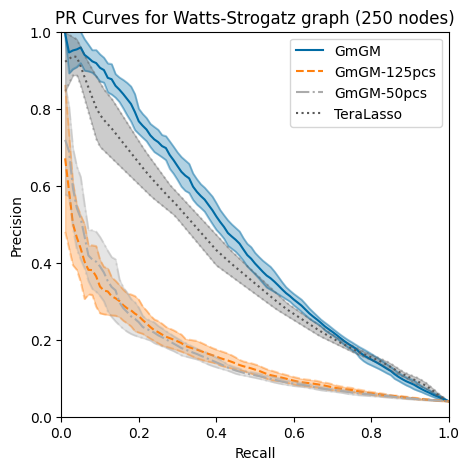

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    random.seed(SEED)
    np.random.seed(SEED)

    # Create a random graph
    num_nodes = 250
    graph = ig.Graph.Watts_Strogatz(1, num_nodes, 5, p=0.8)
    ground_truth = np.array(graph.get_adjacency().data)
    ranks = [125, 50]
    colors = ["blue", "green"]

    # Add diagonal so that it forms a PSD matrix!
    ground_truth = ground_truth / 1.1 + np.eye(num_nodes)

    evals, evecs = np.linalg.eigh(ground_truth)

    # Keep only top half
    ground_truth_low_rank = (
        evecs[:, -num_nodes//2:]
        @ np.diag(evals[-num_nodes//2:])
        @ evecs[:, -num_nodes//2:].T
    )

    explained_variances = {}

    fig, (ax1) = plt.subplots(figsize=(5, 5))


    algorithms = (
        ["GmGM"]
        + [f"GmGM-{rank}pcs" for rank in ranks]
        + ["TeraLasso"]
        #+ ["Graphical Lasso"]
    )
    for idx, algorithm in enumerate(algorithms):
        print(f"Running {algorithm}")
        ps = []
        rs = []

        explained_variances[algorithm] = []

        num_trials = 10
        for i in range(num_trials):
            print(f"\tTrial {i} of {num_trials}")
            output = fast_kronecker_normal(
                [ground_truth_low_rank, ground_truth_low_rank],
                1
            )
            dataset = GmGM.Dataset(
                dataset={"data": output},
                structure={"data": ("", "rows", "columns")}
            )
            result = None
            run_alg = None
            if algorithm == "GmGM":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=None,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = 1
            elif algorithm == "TeraLasso":
                def run_alg(reg_param):
                    return bg.TeraLasso(
                        dataset,
                        reg_param,
                        use_nonparanormal_skeptic=False
                    ).precision_matrices["rows"].toarray()
                explained_variance = 1
            elif algorithm == "DNNLasso":
                result = bg.DNNLasso(
                    dataset,
                    0,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "Graphical Lasso":
                result = bg.GLasso(
                    dataset,
                    0.1,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "GmGM-pcs":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=num_nodes // 2,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = result.es["rows"].sum() / result.total_variance["rows"]
            else:
                for rank in ranks:
                    if algorithm == f"GmGM-{rank}pcs":
                        result = GmGM.GmGM(
                            dataset,
                            to_keep=1,
                            threshold_method="overall-col-weighted",
                            min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                            n_comps=rank,
                            verbose=False,
                            centering_method=None,
                            use_nonparanormal_skeptic=False,
                            nonparanormal_evec_backend="COCA",
                            readonly=False,
                            calculate_explained_variance=True,
                            batch_size=1000
                        )
                        explained_variance = result.es["columns"].sum() / result.total_variance["columns"]
            if result is None and run_alg is None:
                raise Exception("Unknown algorithm")

            if algorithm != "TeraLasso":
                ys, xs = pr_curve(ground_truth, result.precision_matrices["rows"].toarray())
            else:
                # Manually chosen bounds to cover span from ~perfect recall to ~perfect precision
                reg_params = 10**np.linspace(-2.5, -0.5, 25)
                ys, xs = pr_curve_teralasso(ground_truth, run_alg, reg_params)
            ps.append(ys)
            rs.append(xs)
            #ax.plot(xs, ys)

            explained_variances[algorithm].append(explained_variance)

        num_points = 100
        xs = np.linspace(0, 1, num_points)

        if algorithm == "GmGM":
            label = "GmGM"
        elif algorithm == "GmGM-pcs":
            label = f"GmGM-{num_nodes//2}pcs"
        elif algorithm == "TeraLasso":
            label = "TeraLasso"
        elif algorithm == "DNNLasso":
            label = "DNNLasso"
        elif algorithm == "Graphical Lasso":
            label = "Graphical Lasso"
        else:
            for col, rank in zip(colors, ranks):
                if algorithm == f"GmGM-{rank}pcs":
                    label = f"GmGM-{rank}pcs"

        lineplot = ax1.plot(-1, -1)#, label=label)
        xs = np.linspace(0.01, 1, 100)
        min_ys = np.zeros(100) + 1
        max_ys = np.zeros(100)
        for p, r in zip(ps, rs):
            f = scipy.interpolate.interp1d(r, p, kind='linear', fill_value='extrapolate')
            min_ys = np.minimum(min_ys, f(xs))
            max_ys = np.maximum(max_ys, f(xs))
            #plt.plot(xs, f(xs), color='black', alpha=0.1)

        ax1.plot(
            xs,
            min_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            max_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            (min_ys + max_ys) / 2,
            color=lineplot[0].get_color(),
            label=label,
            linestyle=lines[idx]
        )
        ax1.fill_between(
            xs,
            min_ys,
            max_ys,
            color=lineplot[0].get_color(),
            alpha=0.3
        )#, hatch=hatches[idx]+hatches[idx])

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title(f'PR Curves for Watts-Strogatz graph ({num_nodes} nodes)')
    ax1.legend()

    # On ax2, do a box-and-whiskers plot of explained variances
    # ax2.boxplot(
    #     [
    #         list(explained_variances["GmGM"]),
    #         #list(explained_variances["GmGM-pcs"])
    #     ]
    #     +
    #     [
    #         list(explained_variances[f"GmGM-{rank}pcs"])
    #         for rank in ranks
    #     ]
    #     +
    #     [
    #         #list(explained_variances["TeraLasso"]),
    #         #list(explained_variances["Graphical Lasso"])
    #     ],
    #     labels=algorithms
    # )

    # ax2.set_title("Explained Variance; Box and Whiskers")
    # ax2.set_ylabel("Explained Variance")
    # ax2.set_ylim(0, 1.01)

    # Rotate x-axis labels
    # ax2.tick_params(axis='x', labelrotation=90)
    fig.savefig('./figures/250-nodes-pr-watts-strogatz.pdf', bbox_inches="tight")
    pass

Running GmGM
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-125pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-50pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running TeraLasso
	Trial 0 of 10
TeraLasso lambda: 0.0031622776601683794
TeraLasso lambda: 0.003831186849557289
TeraLasso lambda: 0.004641588833612777
TeraLasso lambda: 0.005623413251903491
TeraLasso lambda: 0.006812920690579615
TeraLasso lambda: 0.008254041852680182
TeraLasso lambda: 0.01
TeraLasso lambda: 0.012115276586285882
TeraLasso lambda: 0.01467799267622069
TeraLasso lambda: 0.01778279410038923
TeraLasso lambda: 0.021544346900318832
TeraLasso lambda: 0.026101572156825358
TeraLasso lamb

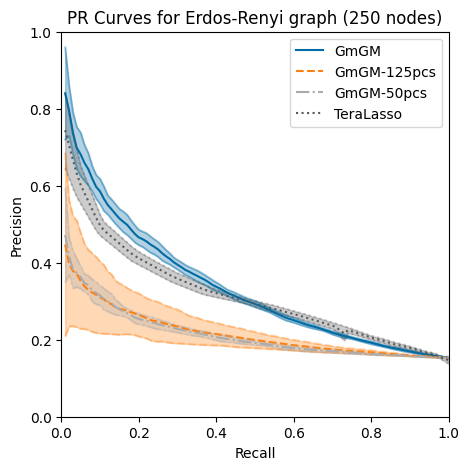

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    random.seed(SEED)
    np.random.seed(SEED)

    # Create a random graph
    num_nodes = 250
    graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=0.15)
    ground_truth = np.array(graph.get_adjacency().data)
    ranks = [125, 50]
    colors = ["blue", "green"]

    # Add diagonal so that it forms a PSD matrix!
    ground_truth = ground_truth / 1.1 + np.eye(num_nodes)

    evals, evecs = np.linalg.eigh(ground_truth)

    # Keep only top half
    ground_truth_low_rank = (
        evecs[:, -num_nodes//2:]
        @ np.diag(evals[-num_nodes//2:])
        @ evecs[:, -num_nodes//2:].T
    )

    explained_variances = {}

    fig, (ax1) = plt.subplots(figsize=(5, 5))


    algorithms = (
        ["GmGM"]
        + [f"GmGM-{rank}pcs" for rank in ranks]
        + ["TeraLasso"]
        #+ ["Graphical Lasso"]
    )
    for idx, algorithm in enumerate(algorithms):
        print(f"Running {algorithm}")
        ps = []
        rs = []

        explained_variances[algorithm] = []

        num_trials = 10
        for i in range(num_trials):
            print(f"\tTrial {i} of {num_trials}")
            output = fast_kronecker_normal(
                [ground_truth_low_rank, ground_truth_low_rank],
                1
            )
            dataset = GmGM.Dataset(
                dataset={"data": output},
                structure={"data": ("", "rows", "columns")}
            )
            result = None
            run_alg = None
            if algorithm == "GmGM":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=None,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = 1
            elif algorithm == "TeraLasso":
                def run_alg(reg_param):
                    return bg.TeraLasso(
                        dataset,
                        reg_param,
                        use_nonparanormal_skeptic=False
                    ).precision_matrices["rows"].toarray()
                explained_variance = 1
            elif algorithm == "DNNLasso":
                result = bg.DNNLasso(
                    dataset,
                    0,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "Graphical Lasso":
                result = bg.GLasso(
                    dataset,
                    0.1,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "GmGM-pcs":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=num_nodes // 2,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = result.es["rows"].sum() / result.total_variance["rows"]
            else:
                for rank in ranks:
                    if algorithm == f"GmGM-{rank}pcs":
                        result = GmGM.GmGM(
                            dataset,
                            to_keep=1,
                            threshold_method="overall-col-weighted",
                            min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                            n_comps=rank,
                            verbose=False,
                            centering_method=None,
                            use_nonparanormal_skeptic=False,
                            nonparanormal_evec_backend="COCA",
                            readonly=False,
                            calculate_explained_variance=True,
                            batch_size=1000
                        )
                        explained_variance = result.es["columns"].sum() / result.total_variance["columns"]
            if result is None and run_alg is None:
                raise Exception("Unknown algorithm")

            if algorithm != "TeraLasso":
                ys, xs = pr_curve(ground_truth, result.precision_matrices["rows"].toarray())
            else:
                # Manually chosen bounds to cover span from ~perfect recall to ~perfect precision
                reg_params = 10**np.linspace(-2.5, -0.5, 25)
                ys, xs = pr_curve_teralasso(ground_truth, run_alg, reg_params)
            ps.append(ys)
            rs.append(xs)
            #ax.plot(xs, ys)

            explained_variances[algorithm].append(explained_variance)

        num_points = 100
        xs = np.linspace(0, 1, num_points)

        if algorithm == "GmGM":
            label = "GmGM"
        elif algorithm == "GmGM-pcs":
            label = f"GmGM-{num_nodes//2}pcs"
        elif algorithm == "TeraLasso":
            label = "TeraLasso"
        elif algorithm == "DNNLasso":
            label = "DNNLasso"
        elif algorithm == "Graphical Lasso":
            label = "Graphical Lasso"
        else:
            for col, rank in zip(colors, ranks):
                if algorithm == f"GmGM-{rank}pcs":
                    label = f"GmGM-{rank}pcs"

        lineplot = ax1.plot(-1, -1)#, label=label)
        xs = np.linspace(0.01, 1, 100)
        min_ys = np.zeros(100) + 1
        max_ys = np.zeros(100)
        for p, r in zip(ps, rs):
            f = scipy.interpolate.interp1d(r, p, kind='linear', fill_value='extrapolate')
            min_ys = np.minimum(min_ys, f(xs))
            max_ys = np.maximum(max_ys, f(xs))
            #plt.plot(xs, f(xs), color='black', alpha=0.1)

        ax1.plot(
            xs,
            min_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            max_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            (min_ys + max_ys) / 2,
            color=lineplot[0].get_color(),
            label=label,
            linestyle=lines[idx]
        )
        ax1.fill_between(
            xs,
            min_ys,
            max_ys,
            color=lineplot[0].get_color(),
            alpha=0.3
        )#, hatch=hatches[idx]+hatches[idx])

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title(f'PR Curves for Erdos-Renyi graph ({num_nodes} nodes)')
    ax1.legend()

    # On ax2, do a box-and-whiskers plot of explained variances
    # ax2.boxplot(
    #     [
    #         list(explained_variances["GmGM"]),
    #         #list(explained_variances["GmGM-pcs"])
    #     ]
    #     +
    #     [
    #         list(explained_variances[f"GmGM-{rank}pcs"])
    #         for rank in ranks
    #     ]
    #     +
    #     [
    #         #list(explained_variances["TeraLasso"]),
    #         #list(explained_variances["Graphical Lasso"])
    #     ],
    #     labels=algorithms
    # )

    # ax2.set_title("Explained Variance; Box and Whiskers")
    # ax2.set_ylabel("Explained Variance")
    # ax2.set_ylim(0, 1.01)

    # Rotate x-axis labels
    # ax2.tick_params(axis='x', labelrotation=90)
    fig.savefig('./figures/250-nodes-pr-erdos-renyi.pdf', bbox_inches="tight")
    pass

Running GmGM
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-500pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-125pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10


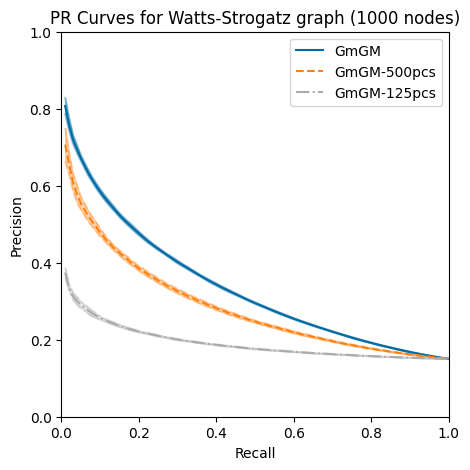

In [89]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    random.seed(SEED)
    np.random.seed(SEED)

    # Create a random graph
    num_nodes = 1000
    graph = ig.Graph.Watts_Strogatz(1, num_nodes, 75, p=0.8)
    ground_truth = np.array(graph.get_adjacency().data)
    ranks = [500, 125]
    colors = ["blue", "green"]

    # Add diagonal so that it forms a PSD matrix!
    ground_truth = ground_truth / 1.1 + np.eye(num_nodes)

    evals, evecs = np.linalg.eigh(ground_truth)

    # Keep only top half
    ground_truth_low_rank = (
        evecs[:, -num_nodes//2:]
        @ np.diag(evals[-num_nodes//2:])
        @ evecs[:, -num_nodes//2:].T
    )

    explained_variances = {}

    fig, (ax1) = plt.subplots(figsize=(5, 5))


    algorithms = (
        ["GmGM"]
        + [f"GmGM-{rank}pcs" for rank in ranks]
        #+ ["TeraLasso"]
        #+ ["Graphical Lasso"]
    )
    for idx, algorithm in enumerate(algorithms):
        print(f"Running {algorithm}")
        ps = []
        rs = []

        explained_variances[algorithm] = []

        num_trials = 10
        for i in range(num_trials):
            print(f"\tTrial {i} of {num_trials}")
            output = fast_kronecker_normal(
                [ground_truth_low_rank, ground_truth_low_rank],
                1
            )
            dataset = GmGM.Dataset(
                dataset={"data": output},
                structure={"data": ("", "rows", "columns")}
            )
            result = None
            run_alg = None
            if algorithm == "GmGM":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=None,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = 1
            elif algorithm == "TeraLasso":
                def run_alg(reg_param):
                    return bg.TeraLasso(
                        dataset,
                        reg_param,
                        use_nonparanormal_skeptic=False
                    ).precision_matrices["rows"].toarray()
                explained_variance = 1
            elif algorithm == "DNNLasso":
                result = bg.DNNLasso(
                    dataset,
                    0,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "Graphical Lasso":
                result = bg.GLasso(
                    dataset,
                    0.1,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "GmGM-pcs":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=num_nodes // 2,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = result.es["rows"].sum() / result.total_variance["rows"]
            else:
                for rank in ranks:
                    if algorithm == f"GmGM-{rank}pcs":
                        result = GmGM.GmGM(
                            dataset,
                            to_keep=1,
                            threshold_method="overall-col-weighted",
                            min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                            n_comps=rank,
                            verbose=False,
                            centering_method=None,
                            use_nonparanormal_skeptic=False,
                            nonparanormal_evec_backend="COCA",
                            readonly=False,
                            calculate_explained_variance=True,
                            batch_size=1000
                        )
                        explained_variance = result.es["columns"].sum() / result.total_variance["columns"]
            if result is None and run_alg is None:
                raise Exception("Unknown algorithm")

            if algorithm != "TeraLasso":
                ys, xs = pr_curve(ground_truth, result.precision_matrices["rows"].toarray())
            else:
                # Manually chosen bounds to cover span from ~perfect recall to ~perfect precision
                reg_params = 10**np.linspace(-2.5, -0.5, 25)
                ys, xs = pr_curve_teralasso(ground_truth, run_alg, reg_params)
            ps.append(ys)
            rs.append(xs)
            #ax.plot(xs, ys)

            explained_variances[algorithm].append(explained_variance)

        num_points = 100
        xs = np.linspace(0, 1, num_points)

        if algorithm == "GmGM":
            label = "GmGM"
        elif algorithm == "GmGM-pcs":
            label = f"GmGM-{num_nodes//2}pcs"
        elif algorithm == "TeraLasso":
            label = "TeraLasso"
        elif algorithm == "DNNLasso":
            label = "DNNLasso"
        elif algorithm == "Graphical Lasso":
            label = "Graphical Lasso"
        else:
            for col, rank in zip(colors, ranks):
                if algorithm == f"GmGM-{rank}pcs":
                    label = f"GmGM-{rank}pcs"

        lineplot = ax1.plot(-1, -1)#, label=label)
        xs = np.linspace(0.01, 1, 100)
        min_ys = np.zeros(100) + 1
        max_ys = np.zeros(100)
        for p, r in zip(ps, rs):
            f = scipy.interpolate.interp1d(r, p, kind='linear', fill_value='extrapolate')
            min_ys = np.minimum(min_ys, f(xs))
            max_ys = np.maximum(max_ys, f(xs))
            #plt.plot(xs, f(xs), color='black', alpha=0.1)

        ax1.plot(
            xs,
            min_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            max_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            (min_ys + max_ys) / 2,
            color=lineplot[0].get_color(),
            label=label,
            linestyle=lines[idx]
        )
        ax1.fill_between(
            xs,
            min_ys,
            max_ys,
            color=lineplot[0].get_color(),
            alpha=0.3
        )#, hatch=hatches[idx]+hatches[idx])

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title(f'PR Curves for Watts-Strogatz graph ({num_nodes} nodes)')
    ax1.legend()

    # On ax2, do a box-and-whiskers plot of explained variances
    # ax2.boxplot(
    #     [
    #         list(explained_variances["GmGM"]),
    #         #list(explained_variances["GmGM-pcs"])
    #     ]
    #     +
    #     [
    #         list(explained_variances[f"GmGM-{rank}pcs"])
    #         for rank in ranks
    #     ]
    #     +
    #     [
    #         #list(explained_variances["TeraLasso"]),
    #         #list(explained_variances["Graphical Lasso"])
    #     ],
    #     labels=algorithms
    # )

    # ax2.set_title("Explained Variance; Box and Whiskers")
    # ax2.set_ylabel("Explained Variance")
    # ax2.set_ylim(0, 1.01)

    # Rotate x-axis labels
    # ax2.tick_params(axis='x', labelrotation=90)
    fig.savefig('./figures/1000-nodes-pr-watts-strogatz.pdf', bbox_inches="tight")
    pass

Running GmGM
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-500pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10
Running GmGM-125pcs
	Trial 0 of 10
	Trial 1 of 10
	Trial 2 of 10
	Trial 3 of 10
	Trial 4 of 10
	Trial 5 of 10
	Trial 6 of 10
	Trial 7 of 10
	Trial 8 of 10
	Trial 9 of 10


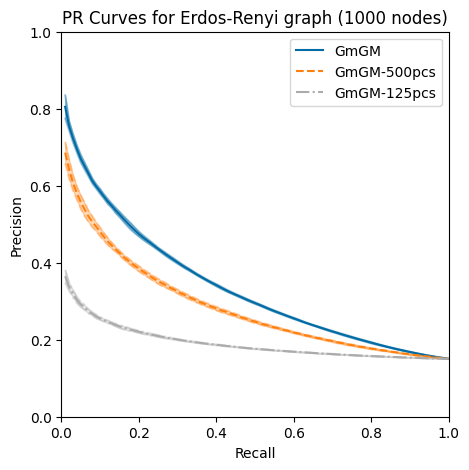

In [88]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    random.seed(SEED)
    np.random.seed(SEED)

    # Create a random graph
    num_nodes = 1000
    graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=0.15)
    ground_truth = np.array(graph.get_adjacency().data)
    ranks = [500, 125]
    colors = ["blue", "green"]

    # Add diagonal so that it forms a PSD matrix!
    ground_truth = ground_truth / 1.1 + np.eye(num_nodes)

    evals, evecs = np.linalg.eigh(ground_truth)

    # Keep only top half
    ground_truth_low_rank = (
        evecs[:, -num_nodes//2:]
        @ np.diag(evals[-num_nodes//2:])
        @ evecs[:, -num_nodes//2:].T
    )

    explained_variances = {}

    fig, (ax1) = plt.subplots(figsize=(5, 5))


    algorithms = (
        ["GmGM"]
        + [f"GmGM-{rank}pcs" for rank in ranks]
        #+ ["TeraLasso"]
        #+ ["Graphical Lasso"]
    )
    for idx, algorithm in enumerate(algorithms):
        print(f"Running {algorithm}")
        ps = []
        rs = []

        explained_variances[algorithm] = []

        num_trials = 10
        for i in range(num_trials):
            print(f"\tTrial {i} of {num_trials}")
            output = fast_kronecker_normal(
                [ground_truth_low_rank, ground_truth_low_rank],
                1
            )
            dataset = GmGM.Dataset(
                dataset={"data": output},
                structure={"data": ("", "rows", "columns")}
            )
            result = None
            run_alg = None
            if algorithm == "GmGM":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=None,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = 1
            elif algorithm == "TeraLasso":
                def run_alg(reg_param):
                    return bg.TeraLasso(
                        dataset,
                        reg_param,
                        use_nonparanormal_skeptic=False
                    ).precision_matrices["rows"].toarray()
                explained_variance = 1
            elif algorithm == "DNNLasso":
                result = bg.DNNLasso(
                    dataset,
                    0,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "Graphical Lasso":
                result = bg.GLasso(
                    dataset,
                    0.1,
                    use_nonparanormal_skeptic=False
                )
                explained_variance = 1
            elif algorithm == "GmGM-pcs":
                result = GmGM.GmGM(
                    dataset,
                    to_keep=1,
                    threshold_method="overall-col-weighted",
                    min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                    n_comps=num_nodes // 2,
                    verbose=False,
                    centering_method=None,
                    use_nonparanormal_skeptic=False,
                    nonparanormal_evec_backend="COCA",
                    readonly=False,
                    calculate_explained_variance=True,
                    batch_size=1000
                )
                explained_variance = result.es["rows"].sum() / result.total_variance["rows"]
            else:
                for rank in ranks:
                    if algorithm == f"GmGM-{rank}pcs":
                        result = GmGM.GmGM(
                            dataset,
                            to_keep=1,
                            threshold_method="overall-col-weighted",
                            min_edges={"rows": num_nodes - 1, "columns": num_nodes - 1},
                            n_comps=rank,
                            verbose=False,
                            centering_method=None,
                            use_nonparanormal_skeptic=False,
                            nonparanormal_evec_backend="COCA",
                            readonly=False,
                            calculate_explained_variance=True,
                            batch_size=1000
                        )
                        explained_variance = result.es["columns"].sum() / result.total_variance["columns"]
            if result is None and run_alg is None:
                raise Exception("Unknown algorithm")

            if algorithm != "TeraLasso":
                ys, xs = pr_curve(ground_truth, result.precision_matrices["rows"].toarray())
            else:
                # Manually chosen bounds to cover span from ~perfect recall to ~perfect precision
                reg_params = 10**np.linspace(-2.5, -0.5, 25)
                ys, xs = pr_curve_teralasso(ground_truth, run_alg, reg_params)
            ps.append(ys)
            rs.append(xs)
            #ax.plot(xs, ys)

            explained_variances[algorithm].append(explained_variance)

        num_points = 100
        xs = np.linspace(0, 1, num_points)

        if algorithm == "GmGM":
            label = "GmGM"
        elif algorithm == "GmGM-pcs":
            label = f"GmGM-{num_nodes//2}pcs"
        elif algorithm == "TeraLasso":
            label = "TeraLasso"
        elif algorithm == "DNNLasso":
            label = "DNNLasso"
        elif algorithm == "Graphical Lasso":
            label = "Graphical Lasso"
        else:
            for col, rank in zip(colors, ranks):
                if algorithm == f"GmGM-{rank}pcs":
                    label = f"GmGM-{rank}pcs"

        lineplot = ax1.plot(-1, -1)#, label=label)
        xs = np.linspace(0.01, 1, 100)
        min_ys = np.zeros(100) + 1
        max_ys = np.zeros(100)
        for p, r in zip(ps, rs):
            f = scipy.interpolate.interp1d(r, p, kind='linear', fill_value='extrapolate')
            min_ys = np.minimum(min_ys, f(xs))
            max_ys = np.maximum(max_ys, f(xs))
            #plt.plot(xs, f(xs), color='black', alpha=0.1)

        ax1.plot(
            xs,
            min_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            max_ys,
            color=lineplot[0].get_color(),
            linestyle=lines[idx],
            alpha=0.3
        )
        ax1.plot(
            xs,
            (min_ys + max_ys) / 2,
            color=lineplot[0].get_color(),
            label=label,
            linestyle=lines[idx]
        )
        ax1.fill_between(
            xs,
            min_ys,
            max_ys,
            color=lineplot[0].get_color(),
            alpha=0.3
        )#, hatch=hatches[idx]+hatches[idx])

    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel('Recall')
    ax1.set_ylabel('Precision')
    ax1.set_title(f'PR Curves for Erdos-Renyi graph ({num_nodes} nodes)')
    ax1.legend()

    # On ax2, do a box-and-whiskers plot of explained variances
    # ax2.boxplot(
    #     [
    #         list(explained_variances["GmGM"]),
    #         #list(explained_variances["GmGM-pcs"])
    #     ]
    #     +
    #     [
    #         list(explained_variances[f"GmGM-{rank}pcs"])
    #         for rank in ranks
    #     ]
    #     +
    #     [
    #         #list(explained_variances["TeraLasso"]),
    #         #list(explained_variances["Graphical Lasso"])
    #     ],
    #     labels=algorithms
    # )

    # ax2.set_title("Explained Variance; Box and Whiskers")
    # ax2.set_ylabel("Explained Variance")
    # ax2.set_ylim(0, 1.01)

    # # Rotate x-axis labels
    # ax2.tick_params(axis='x', labelrotation=90)
    fig.savefig('./figures/1000-nodes-pr-erdos-renyi.pdf', bbox_inches="tight")
    pass